# House Prices – Thực nghiệm cải tiến mô hình với Gradient Boosting (Scikit-learn)
Notebook này thực hiện 5 kịch bản thực nghiệm để kiểm tra sự ảnh hưởng của các tập đặc trưng đối với mô hình GradientBoostingRegressor.
* **Thí nghiệm 1**: Toàn bộ đặc trưng (Baseline).
* **Thí nghiệm 2**: Chỉ đặc trưng dạng số.
* **Thí nghiệm 3**: Chỉ đặc trưng phân loại.
* **Thí nghiệm 4A & 4B**: Chọn lọc đặc trưng quan trọng theo ngưỡng Mean và Median.

## 1. Import thư viện

Các thư viện được sử dụng:
- `pandas`, `numpy`: xử lý dữ liệu
- `matplotlib`, `seaborn`: trực quan hóa
- `scikit-learn`: preprocessing, pipeline, cross-validation và mô hình

In [146]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectFromModel

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 2. Đọc dữ liệu

Kaggle cung cấp:
- `train.csv`: 1460 dòng, gồm các đặc trưng và `SalePrice`
- `test.csv`: 1459 dòng, không có `SalePrice`

`Id` chỉ là mã định danh và sẽ không được sử dụng làm đặc trưng.

In [147]:
TRAIN_PATH = "/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv"
TEST_PATH = "/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

Train shape: (1460, 81)
Test shape : (1459, 80)


In [148]:
display(train.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [149]:
print("Train info:")
train.info()

print("\nTest info:")
test.info()

Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 

## 3. Kiểm tra dữ liệu thiếu

House Prices có nhiều giá trị thiếu. Không xóa toàn bộ các dòng có missing.

Thay vào đó:
- Numerical: điền bằng median
- Categorical: điền bằng giá trị xuất hiện thường xuyên nhất (`most_frequent`)
- Việc xử lý được đặt **bên trong Pipeline** để tránh data leakage.

Các cột có missing values trong train:


,Missing
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


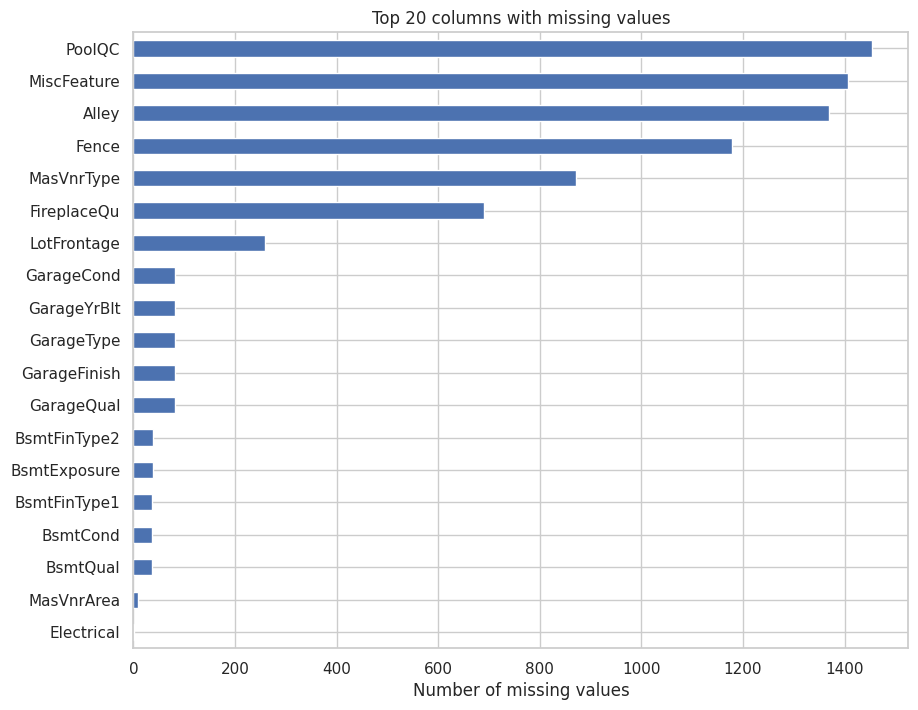

In [150]:
missing_train = train.isnull().sum().sort_values(ascending=False)
missing_train = missing_train[missing_train > 0]

print("Các cột có missing values trong train:")
display(missing_train.to_frame("Missing"))

plt.figure(figsize=(10, 8))
missing_train.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 columns with missing values")
plt.xlabel("Number of missing values")
plt.show()

## 4. Phân tích biến mục tiêu `SalePrice`

Mô hình sẽ học trên `log1p(SalePrice)` thay vì trực tiếp trên `SalePrice`.
Điều này giúp giảm ảnh hưởng của các giá nhà cực lớn và phù hợp với cách đánh giá RMSLE của cuộc thi.

Sau khi dự đoán, dùng `expm1()` để đưa kết quả về giá nhà ban đầu.

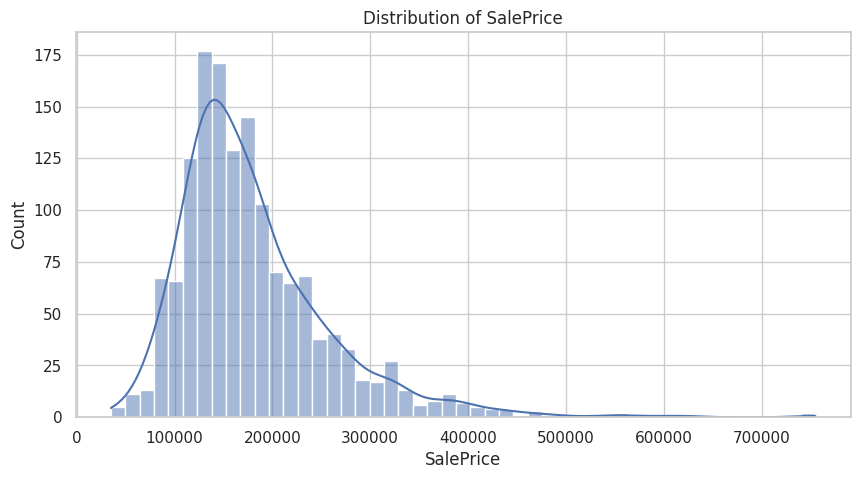

In [151]:
plt.figure(figsize=(10, 5))
sns.histplot(train["SalePrice"], kde=True)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.show()

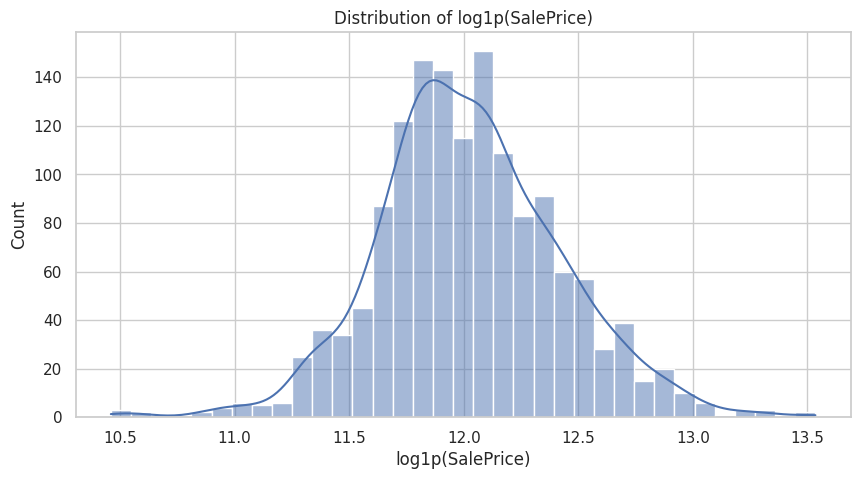

In [152]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(train["SalePrice"]), kde=True)
plt.title("Distribution of log1p(SalePrice)")
plt.xlabel("log1p(SalePrice)")
plt.show()

In [153]:
print(train["SalePrice"].describe())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


## 5. Tách Input và Output

- `y = SalePrice`: biến mục tiêu
- `X`: toàn bộ đặc trưng còn lại
- `Id` được lưu riêng để tạo file submission và loại khỏi `X`

Không đưa `SalePrice` vào `X` vì đây chính là giá trị cần dự đoán.

In [154]:
test_ids = test["Id"].copy()

X = train.drop(columns=["SalePrice", "Id"]).copy()
y = train["SalePrice"].copy()

X_test = test.drop(columns=["Id"]).copy()

print("X shape     :", X.shape)
print("y shape     :", y.shape)
print("X_test shape:", X_test.shape)

X shape     : (1460, 79)
y shape     : (1460,)
X_test shape: (1459, 79)


## 6. Kiểm tra kiểu dữ liệu

Các biến được chia thành:
- Numerical features: số nguyên hoặc số thực
- Categorical features: dữ liệu dạng chuỗi

`OneHotEncoder` sẽ thực hiện encoding
bên trong Pipeline để preprocessing được áp dụng nhất quán cho train và test.

In [155]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Số numerical features :", len(numeric_features))
print("Số categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Số numerical features : 36
Số categorical features: 43

Numerical features:
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Categorical features:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',

## 7. Xây dựng preprocessing pipeline

### Numerical
`SimpleImputer(strategy="median")`

### Categorical
`SimpleImputer(strategy="most_frequent")`
→ `OneHotEncoder(handle_unknown="ignore")`

`handle_unknown="ignore"` giúp mô hình không lỗi nếu test có một category
không xuất hiện trong train.

In [156]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Cấu hình Gradient Boosting Regressor[cite: 10]


In [157]:
regressor = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

y_log = np.log1p(y)

## Hàm đánh giá thực nghiệm bằng Cross Validation 5-Fold

In [158]:
def run_experiment(experiment_name, pipeline, X_data, y_data):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(
        pipeline, X_data, y_data, cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1
    )
    rmse = -cv_scores.mean()
    print(f"[{experiment_name}]")
    print(f"Scores : {-cv_scores}")
    print(f"RMSE   : {rmse:.5f}\n" + "-"*60)
    return rmse

# Dictionary để lưu kết quả các kịch bản
results = {}

## 8. Xây dựng mô hình Gradient Boosting

Các tham số được sử dụng:

- `n_estimators=300`: 300 cây
- `learning_rate=0.05`: tốc độ học
- `max_depth=4`: độ sâu tối đa của mỗi cây
- `random_state=42`: đảm bảo kết quả có thể tái lập

Mô hình được đặt ngay sau preprocessing trong cùng một Pipeline.

## Thí nghiệm 1

In [159]:
preprocessor_all = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_all),
    ("regressor", regressor)
])

model_pipeline
results["TN 1 (All)"] = run_experiment("Thí nghiệm 1: Toàn bộ đặc trưng", model_pipeline, X, y_log)

[Thí nghiệm 1: Toàn bộ đặc trưng]
Scores : [0.1365222  0.11159401 0.16767138 0.13468921 0.10718009]
RMSE   : 0.13153
------------------------------------------------------------


## Thí nghiệm 2

In [160]:
preprocessor_num_only = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features)
])

pipeline_num_only = Pipeline(steps=[
    ("preprocessor", preprocessor_num_only),
    ("regressor", regressor)
])

results["TN 2 (Num Only)"] = run_experiment("Thí nghiệm 2: Chỉ Numerical", pipeline_num_only, X, y_log)

[Thí nghiệm 2: Chỉ Numerical]
Scores : [0.14285912 0.11565938 0.17387576 0.14237064 0.1149729 ]
RMSE   : 0.13795
------------------------------------------------------------


## Thí nghiệm 3

In [161]:
preprocessor_cat_only = ColumnTransformer(transformers=[
    ("cat", categorical_transformer, categorical_features)
])

pipeline_cat_only = Pipeline(steps=[
    ("preprocessor", preprocessor_cat_only),
    ("regressor", regressor)
])

results["TN 3 (Cat Only)"] = run_experiment("Thí nghiệm 3: Chỉ Categorical", pipeline_cat_only, X, y_log)

[Thí nghiệm 3: Chỉ Categorical]
Scores : [0.18327773 0.18742868 0.18455562 0.20596641 0.17816955]
RMSE   : 0.18788
------------------------------------------------------------


## Thí nghiệm 4A

In [162]:
selector_mean = SelectFromModel(
    GradientBoostingRegressor(n_estimators=100, random_state=42), 
    threshold="mean"
)

pipeline_selection_mean = Pipeline(steps=[
    ("preprocessor", preprocessor_all),
    ("selector", selector_mean),
    ("regressor", regressor)
])

results["TN 4A (Select Mean)"] = run_experiment("Thí nghiệm 4A: Chọn đặc trưng (Ngưỡng Mean)", pipeline_selection_mean, X, y_log)

[Thí nghiệm 4A: Chọn đặc trưng (Ngưỡng Mean)]
Scores : [0.14277099 0.11688238 0.17654461 0.1370998  0.11209184]
RMSE   : 0.13708
------------------------------------------------------------


## Thí nghiệm 4B

In [163]:
selector_median = SelectFromModel(
    GradientBoostingRegressor(n_estimators=100, random_state=42), 
    threshold="median"
)

pipeline_selection_median = Pipeline(steps=[
    ("preprocessor", preprocessor_all),
    ("selector", selector_median),
    ("regressor", regressor)
])

results["TN 4B (Select Median)"] = run_experiment("Thí nghiệm 4B: Chọn đặc trưng (Ngưỡng Median)", pipeline_selection_median, X, y_log)

[Thí nghiệm 4B: Chọn đặc trưng (Ngưỡng Median)]
Scores : [0.1365222  0.11159401 0.16767138 0.13468921 0.10718009]
RMSE   : 0.13153
------------------------------------------------------------


# Vẽ biểu đồ so sánh RMSE giữa 5 kịch bản


Dữ liệu chuẩn bị vẽ: {'TN 1 (All)': np.float64(0.13153137854904115), 'TN 2 (Num Only)': np.float64(0.13794755674755116), 'TN 3 (Cat Only)': np.float64(0.18787959849583208), 'TN 4A (Select Mean)': np.float64(0.13707792271769814), 'TN 4B (Select Median)': np.float64(0.13153137854904115)}


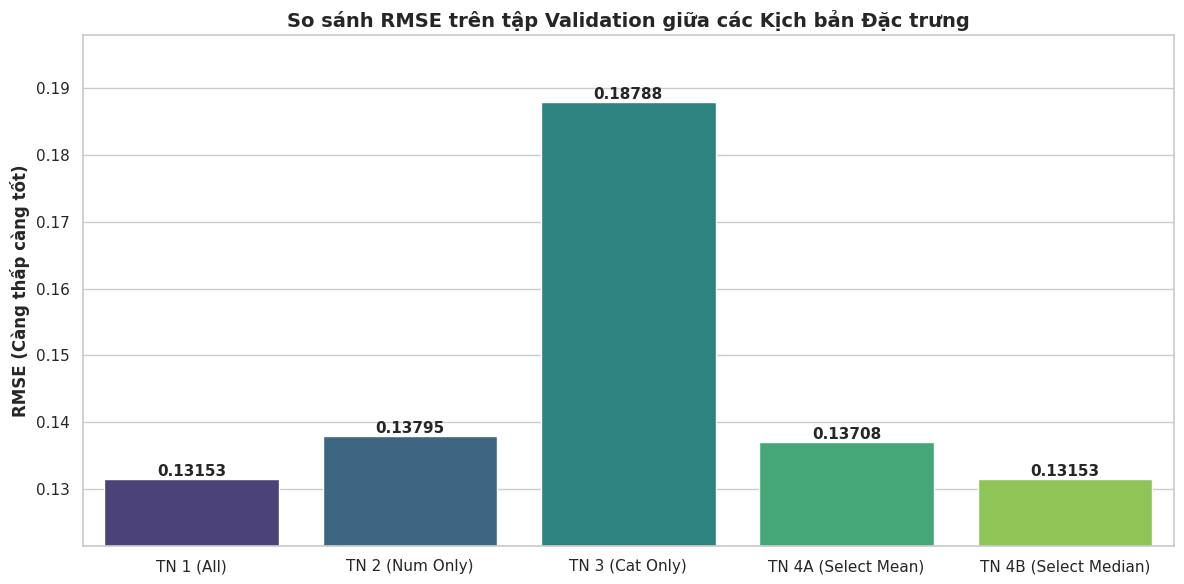

In [164]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Kiểm tra xem dictionary 'results' đã có dữ liệu từ Ô 6 chưa
if not results:
    print("LỖI: Biến 'results' đang trống! Bạn vui lòng chạy lại Ô 6 (Thực thi các thí nghiệm) và đợi chạy xong trước khi vẽ biểu đồ.")
else:
    print("Dữ liệu chuẩn bị vẽ:", results)
    
    # Vẽ biểu đồ so sánh RMSE giữa 5 kịch bản
    plt.figure(figsize=(12, 6))
    sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")

    # Điều chỉnh trục y để hiển thị rõ sự khác biệt
    min_rmse = min(results.values()) - 0.01
    max_rmse = max(results.values()) + 0.01
    plt.ylim(min_rmse, max_rmse)

    plt.ylabel("RMSE (Càng thấp càng tốt)", fontweight='bold')
    plt.title("So sánh RMSE trên tập Validation giữa các Kịch bản Đặc trưng", fontsize=14, fontweight='bold')

    # Hiển thị số liệu trực tiếp trên các cột
    for i, v in enumerate(results.values()):
        plt.text(i, v + 0.0005, f"{v:.5f}", ha='center', fontweight='bold', fontsize=11)

    plt.tight_layout()
    plt.show()

## 9. Cross Validation

Sử dụng 5-Fold Cross Validation.

Target được biến đổi:

`log1p(SalePrice)`

Metric:

`RMSE(log1p(SalePrice))`

Giá trị càng nhỏ càng tốt.

Do scoring là RMSE trên log-price, kết quả này tương ứng với RMSLE
khi dự đoán giá nhà dương.

In [165]:


kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model_pipeline,
    X,
    y_log,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

cv_rmse = -cv_scores

print("5-Fold CV RMSE on log1p(SalePrice):")
print("Scores:", cv_rmse)
print(f"Mean  : {cv_rmse.mean():.4f}")
print(f"Std   : {cv_rmse.std():.4f}")

5-Fold CV RMSE on log1p(SalePrice):
Scores: [0.1365222  0.11159401 0.16767138 0.13468921 0.10718009]
Mean  : 0.1315
Std   : 0.0216


## 10. Huấn luyện mô hình trên toàn bộ training set

Sau khi đánh giá bằng Cross Validation, mô hình được fit trên toàn bộ `train.csv`
để tận dụng tất cả dữ liệu trước khi dự đoán `test.csv`.

In [166]:
pipelines = {
    "TN 1 (All)": model_pipeline,
    "TN 2 (Num Only)": pipeline_num_only,
    "TN 3 (Cat Only)": pipeline_cat_only,
    "TN 4A (Select Mean)": pipeline_selection_mean,
    "TN 4B (Select Median)": pipeline_selection_median
}

# 2. Tìm ra thí nghiệm có RMSE thấp nhất từ dictionary 'results'
best_experiment = min(results, key=results.get)
best_rmse = results[best_experiment]
best_pipeline = pipelines[best_experiment]

print(f"🌟 MÔ HÌNH TỐT NHẤT: {best_experiment} (RMSE = {best_rmse:.5f})")
print("Đang huấn luyện mô hình tốt nhất trên toàn bộ tập train...")

# 3. Huấn luyện mô hình tự động được chọn
best_pipeline.fit(X, y_log)

🌟 MÔ HÌNH TỐT NHẤT: TN 1 (All) (RMSE = 0.13153)
Đang huấn luyện mô hình tốt nhất trên toàn bộ tập train...


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['MSSubClass', 'LotFrontage',
                                                   'LotArea', 'OverallQual',
                                                   'OverallCond', 'YearBuilt',
                                                   'YearRemodAdd', 'MasVnrArea',
                                                   'BsmtFinSF1', 'BsmtFinSF2',
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQualFinSF', 'GrLivArea',
                                                   'BsmtFull...
                                                   'Condition2', 'BldgType',
                                                   'HouseStyle', 'RoofStyle',
                                                   'RoofMatl', 'Exterior1st',
                                                   'Exterior2nd', 'MasVnrType',
                                                   'ExterQual', 'ExterCond',
                                                   'Foundation', 'BsmtQual',
                                                   'BsmtCond', 'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'Heating',
                                                   'HeatingQC', 'CentralAir',
                                                   'Electrical', ...])])),
                ('regressor',
                 GradientBoostingRegressor(learning_rate=0.05, max_depth=4,
                                           n_estimators=300,
                                           random_state=42))])

## 11. Dự đoán trên test set

Mô hình trả về dự đoán ở dạng:

`log1p(SalePrice)`

Vì vậy cần dùng:

`np.expm1()`

để chuyển về giá nhà gốc.

In [167]:
log_preds = best_pipeline.predict(X_test)
final_preds = np.expm1(log_preds)

print("Prediction shape:", final_preds.shape)
print("Min prediction :", final_preds.min())
print("Max prediction :", final_preds.max())
print("Mean prediction:", final_preds.mean())

Prediction shape: (1459,)
Min prediction : 35965.01475117302
Max prediction : 623299.5680674395
Mean prediction: 177424.5631469652


## 12. Kiểm tra kết quả dự đoán

Kiểm tra:
- Không có NaN
- Không có giá trị vô hạn
- Không có giá nhà âm

In [168]:
print("NaN:", np.isnan(final_preds).sum())
print("Inf:", np.isinf(final_preds).sum())
print("Negative:", (final_preds < 0).sum())

prediction_summary = pd.Series(final_preds).describe()
display(prediction_summary)

NaN: 0
Inf: 0
Negative: 0


count      1459.000000
mean     177424.563147
std       76119.654068
min       35965.014751
25%      127804.067386
50%      156382.525722
75%      207788.451279
max      623299.568067
dtype: float64

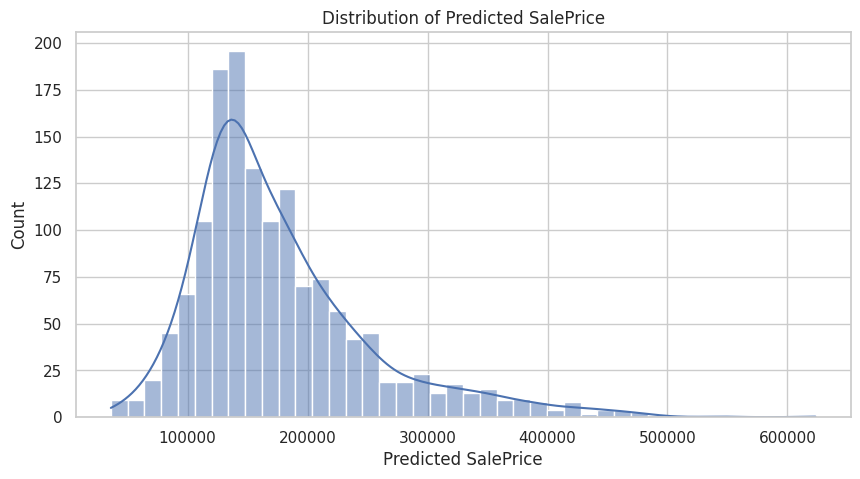

In [169]:
plt.figure(figsize=(10, 5))
sns.histplot(final_preds, kde=True)
plt.title("Distribution of Predicted SalePrice")
plt.xlabel("Predicted SalePrice")
plt.show()

## 13. Tạo file submission

File submission của House Prices chỉ cần 2 cột:

- `Id`
- `SalePrice`

Không đưa các feature khác vào file submission.

In [170]:
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": final_preds
})

submission.to_csv("submission.csv", index=False)

print("Submission shape:", submission.shape)
display(submission.head())

Submission shape: (1459, 2)


,Id,SalePrice
0,1461,122325.635943
1,1462,148318.208084
2,1463,187906.409074
3,1464,190812.175974
4,1465,188538.349748


## 14. Kiểm tra submission cuối cùng

In [171]:
print("Columns:", submission.columns.tolist())
print("Rows   :", len(submission))

print("\nMissing values:")
print(submission.isnull().sum())

print("\nDuplicate Id:", submission["Id"].duplicated().sum())
print("Negative SalePrice:", (submission["SalePrice"] < 0).sum())

print("\nSubmission summary:")
display(submission["SalePrice"].describe())

Columns: ['Id', 'SalePrice']
Rows   : 1459

Missing values:
Id           0
SalePrice    0
dtype: int64

Duplicate Id: 0
Negative SalePrice: 0

Submission summary:


count      1459.000000
mean     177424.563147
std       76119.654068
min       35965.014751
25%      127804.067386
50%      156382.525722
75%      207788.451279
max      623299.568067
Name: SalePrice, dtype: float64

## 15. Kết luận

Quy trình cuối cùng:

`train.csv / test.csv`
→ xác định `X` và `y`
→ bỏ `Id` khỏi feature
→ xử lý missing trong Pipeline
→ One-Hot Encoding categorical features
→ `log1p(SalePrice)`
→ Gradient Boosting Regressor
→ 5-Fold Cross Validation
→ train trên toàn bộ train set
→ dự đoán test
→ `expm1()`
→ tạo `submission_sklearn.csv`

### Kết quả cần báo cáo

- Bài toán: Regression
- Target: `SalePrice`
- Model: `GradientBoostingRegressor`
- Validation: 5-Fold Cross Validation
- Metric: RMSE trên `log1p(SalePrice)` / tương ứng RMSLE
- Submission: `Id`, `SalePrice`